# ARC-AGI models data colector

In [1]:
# Step 0 – Install dependencies (run once)
# scrapy-playwright is required to render the JavaScript leaderboard table.
import subprocess, sys

subprocess.run([sys.executable, "-m", "pip", "install", "scrapy", "scrapy-playwright", "pandas"], check=True)
subprocess.run([sys.executable, "-m", "playwright", "install", "chromium"], check=True)
print("All dependencies installed.")

All dependencies installed.


In [2]:
import subprocess
import sys
from pathlib import Path

import pandas as pd

# In Jupyter, __file__ is not available.
# The kernel CWD is the notebook directory (arc_agi_data_scraper/arc_agi_data_scraper/).
# scrapy.cfg lives one level up — that is the Scrapy project root.
NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent   # …/arc_agi_data_scraper/
CSV_PATH = PROJECT_ROOT / "leaderboard.csv"

# Sanity-check: scrapy.cfg must exist at PROJECT_ROOT
if not (PROJECT_ROOT / "scrapy.cfg").exists():
    raise FileNotFoundError(
        f"scrapy.cfg not found at {PROJECT_ROOT}. "
        "Make sure the Jupyter kernel was started from the notebook directory."
    )

print(f"Project root : {PROJECT_ROOT}")
print(f"CSV output   : {CSV_PATH}")

Project root : C:\Users\a.marin\source\repos\arc-agi\src\arc_agi_data_scraper
CSV output   : C:\Users\a.marin\source\repos\arc-agi\src\arc_agi_data_scraper\leaderboard.csv


In [3]:
# Run the Scrapy spider.
# A subprocess is used to avoid Twisted reactor / Jupyter asyncio conflicts.
result = subprocess.run(
    [sys.executable, "-m", "scrapy", "crawl", "leaderboard"],
    cwd=str(PROJECT_ROOT),
    capture_output=True,
    text=True,
)

print("--- STDOUT ---")
print(result.stdout[-3000:] if len(result.stdout) > 3000 else result.stdout)

if result.returncode != 0:
    print("--- STDERR ---")
    print(result.stderr[-3000:] if len(result.stderr) > 3000 else result.stderr)
    raise RuntimeError(f"Scrapy exited with code {result.returncode}")

print(f"\nSpider finished successfully. CSV saved to: {CSV_PATH}")

--- STDOUT ---


Spider finished successfully. CSV saved to: C:\Users\a.marin\source\repos\arc-agi\src\arc_agi_data_scraper\leaderboard.csv


In [4]:
# Load the CSV produced by the spider
df = pd.read_csv(CSV_PATH)

print(f"Shape: {df.shape}  ({df.shape[0]} rows × {df.shape[1]} columns)")
print("\nColumn dtypes:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (165, 9)  (165 rows × 9 columns)

Column dtypes:
model             object
author            object
date              object
solution_type     object
arc_agi_1        float64
arc_agi_2        float64
arc_agi_3        float64
cost_per_task    float64
total_cost        object
dtype: object

First 5 rows:


,model,author,date,solution_type,arc_agi_1,arc_agi_2,arc_agi_3,cost_per_task,total_cost
0,Claude Opus 4.8 (Low),Anthropic,2026-06-01,CoT,88.0,62.0,NaN,1.680,NaN
1,Claude Opus 4.8 (Medium),Anthropic,2026-06-01,CoT,91.0,71.0,NaN,2.390,NaN
2,Claude Opus 4.8 (High),Anthropic,2026-06-01,CoT,92.0,72.0,1.0,2.740,$10.0K
3,Claude Opus 4.8 (Max),Anthropic,2026-06-01,CoT,92.0,NaN,NaN,2.330,NaN
4,Gemini 3.5 Flash (Minimal),Google,2026-05-19,CoT,48.0,8.0,NaN,0.107,NaN


In [5]:
# Filter: keep only rows that have an ARC-AGI-1 score, sorted best-first
df_arc1 = (
    df[df["arc_agi_1"].notna()]
    .sort_values("arc_agi_1", ascending=False)
    .reset_index(drop=True)
)

print(f"Rows with ARC-AGI-1 score: {len(df_arc1)}")
df_arc1

Rows with ARC-AGI-1 score: 154


,model,author,date,solution_type,arc_agi_1,arc_agi_2,arc_agi_3,cost_per_task,total_cost
0,Stem Grad,Human,NaN,NaN,98.0,NaN,NaN,10.000,NaN
1,Gemini 3.1 Pro (Preview),Google,2026-02-19,CoT,98.0,77.0,NaN,0.962,NaN
2,Human Panel,Human,NaN,NaN,98.0,100.0,NaN,17.000,NaN
3,Gemini 3 Deep Think (2/26),Google,2026-02-12,CoT,96.0,84.0,NaN,13.620,NaN
4,GPT-5.5 Pro (High),OpenAI,2026-04-23,CoT,96.0,84.0,NaN,10.510,NaN
...,...,...,...,...,...,...,...,...,...
149,GPT-5 Nano (Low),OpenAI,2025-08-07,CoT,4.0,0.0,NaN,0.003,NaN
150,GPT-4.1-Mini,OpenAI,2025-04-14,Base LLM,3.0,0.0,NaN,0.014,NaN
151,GPT-5 Nano (Minimal),OpenAI,2025-08-07,CoT,1.0,0.0,NaN,0.003,NaN
152,Llama 4 Scout,Meta,2025-04-05,Base LLM,0.0,0.0,NaN,0.006,NaN


In [6]:
# Filter by author/organisation
# Change AUTHOR to any value from the 'author' column (e.g. "OpenAI", "Google", "xAI")
AUTHOR = "Anthropic"

df_author = df_arc1[df_arc1["author"] == AUTHOR].reset_index(drop=True)
print(f"Rows for '{AUTHOR}': {len(df_author)}")
df_author

Rows for 'Anthropic': 42


,model,author,date,solution_type,arc_agi_1,arc_agi_2,arc_agi_3,cost_per_task,total_cost
0,"Claude Opus 4.6 (120K, High)",Anthropic,2026-02-05,CoT,94.0,69.0,NaN,3.470,NaN
1,Claude 4.7 (High),Anthropic,2026-04-16,CoT,93.0,68.0,NaN,3.170,NaN
2,"Claude Opus 4.6 (120K, Max)",Anthropic,2026-02-05,CoT,93.0,68.0,NaN,3.640,NaN
3,Claude 4.7 (Max),Anthropic,2026-04-16,CoT,92.0,75.0,NaN,7.430,NaN
4,"Claude Opus 4.6 (120K, Medium)",Anthropic,2026-02-05,CoT,92.0,66.0,NaN,2.720,NaN
5,Claude Opus 4.8 (Max),Anthropic,2026-06-01,CoT,92.0,NaN,NaN,2.330,NaN
6,Claude Opus 4.8 (High),Anthropic,2026-06-01,CoT,92.0,72.0,1.0,2.740,$10.0K
7,Claude 4.7 (Low),Anthropic,2026-04-16,CoT,91.0,62.0,NaN,2.380,NaN
8,Claude Opus 4.8 (Medium),Anthropic,2026-06-01,CoT,91.0,71.0,NaN,2.390,NaN
9,Claude 4.7 (Medium),Anthropic,2026-04-16,CoT,91.0,67.0,NaN,2.960,NaN


## Create different plots

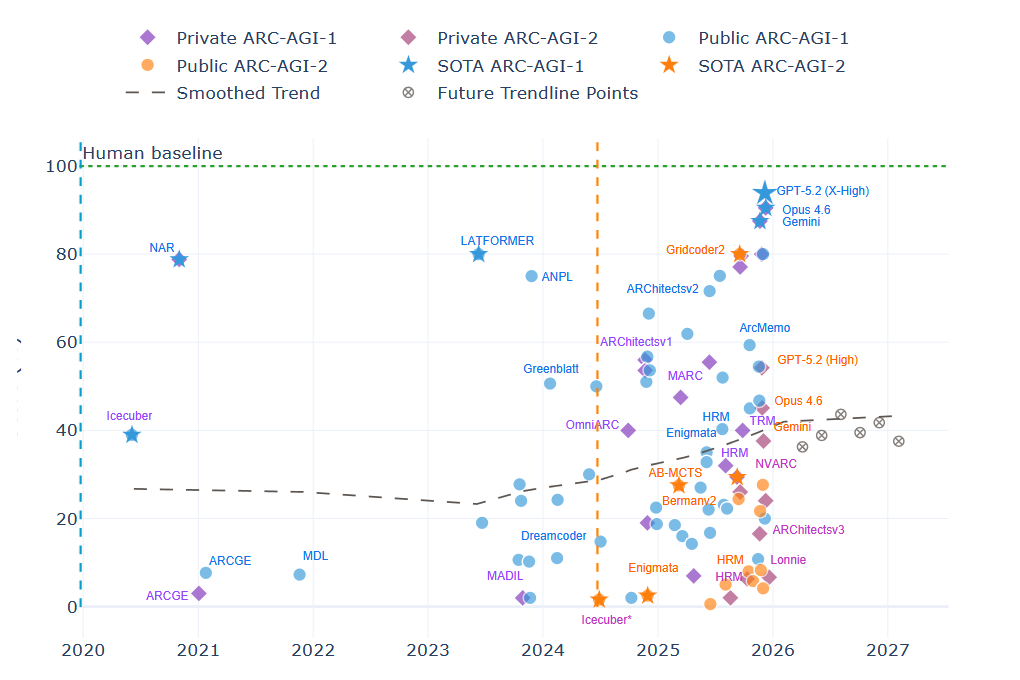
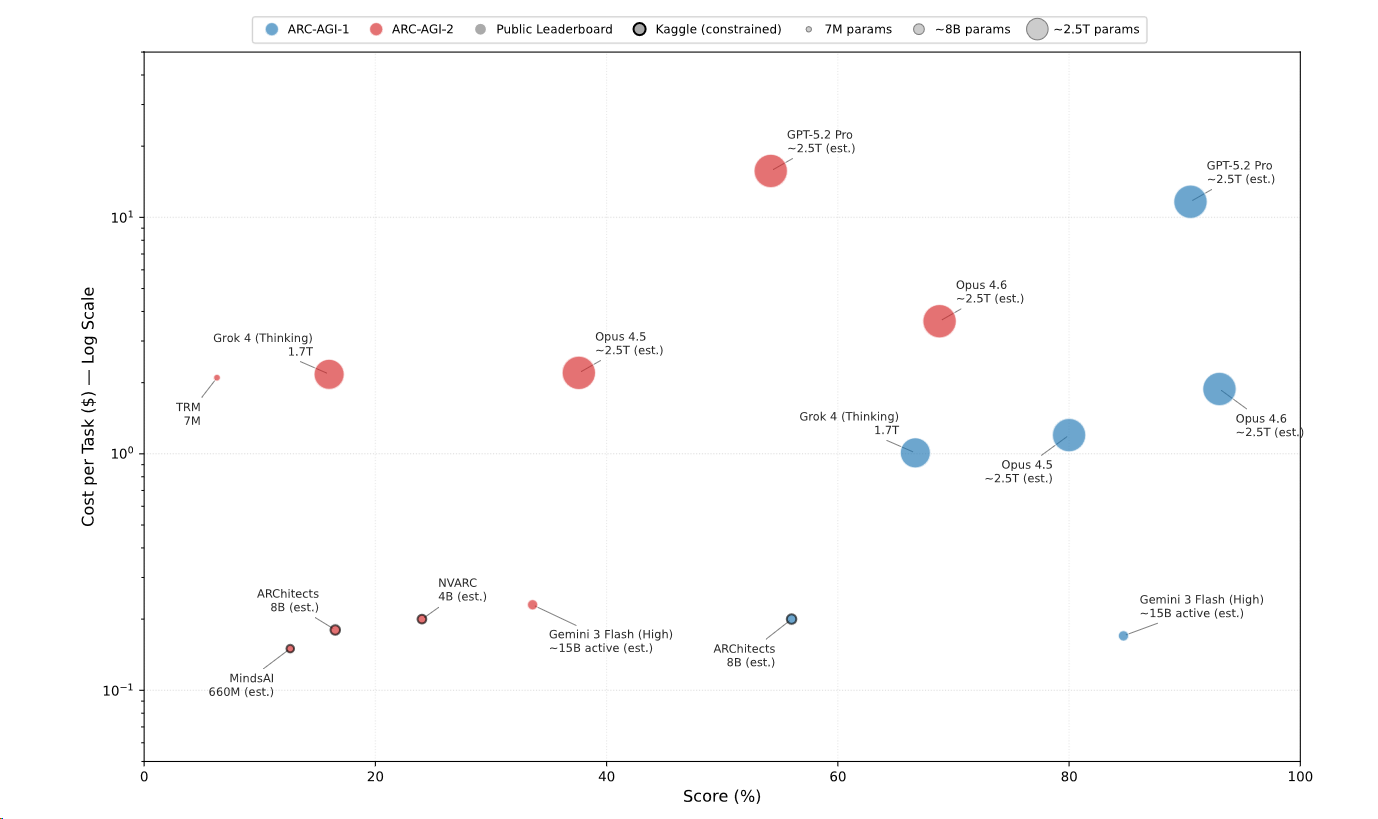

This is a **Time-Series Annotated Scatter Plot**.

It is used to track the performance of various items (in this case, AI models) over a specific time period. The data is categorized by different groups, with specific shapes and colors denoting each category, and it includes reference lines and a trendline to provide context.

Here is a detailed breakdown of the plot's components that you can use as a prompt or instructions to recreate it:

### **Chart Description & Recreation Instructions**

**1. General Layout and Axes**

* **Type:** 2D Scatter Plot.
* **X-axis:** Represents time in years, ranging from 2020 to 2027. Ticks should be placed at each whole year.
* **Y-axis:** Represents a performance score or percentage, ranging from 0 to 100. Major tick intervals should be set at 20 (0, 20, 40, 60, 80, 100).
* **Grid:** Include a very light, subtle grid for both the x and y axes to aid readability. The background should be clean white.

**2. Legend and Categorical Styling**
Position the legend at the top-center of the chart, laid out in three columns. Define the data categories with the following specific marker styles:

* **Private ARC-AGI-1:** Purple diamonds.
* **Private ARC-AGI-2:** Mauve/light pink diamonds.
* **Public ARC-AGI-1:** Light blue circles.
* **Public ARC-AGI-2:** Light orange circles.
* **SOTA ARC-AGI-1:** Blue stars (slightly larger than standard markers).
* **SOTA ARC-AGI-2:** Orange stars (slightly larger than standard markers).
* **Smoothed Trend:** Dark grey dashed line.
* **Future Trendline Points:** Dark grey circles with an 'x' inside.

**3. Data Points and Annotations**

* Scatter the data points across the timeline according to their respective scores and categories.
* **Annotations:** Add text labels next to notable data points (e.g., "GPT-5.2 (X-High)", "Gemini", "NAR", "Icecuber"). The text color of the label must exactly match the color of its corresponding marker. Use a small, clean sans-serif font.

**4. Reference Lines**

* **Horizontal Baseline:** Draw a green dashed line at Y=100. Add the text label "Human baseline" sitting directly on top of this line at the far-left edge.
* **Vertical Markers:**
* Draw a light blue dashed vertical line at X=2020.
* Draw an orange dashed vertical line at approximately mid-2024.



**5. Trendlines**

* Draw a "Smoothed Trend" line using a dark grey dashed stroke. It should start relatively flat (around Y=25) from 2020 to 2023, and then slope upwards through 2024 to 2026.
* Extend the end of this trendline using the "Future Trendline Points" (grey crossed circles) plotted out toward 2026 and 2027.

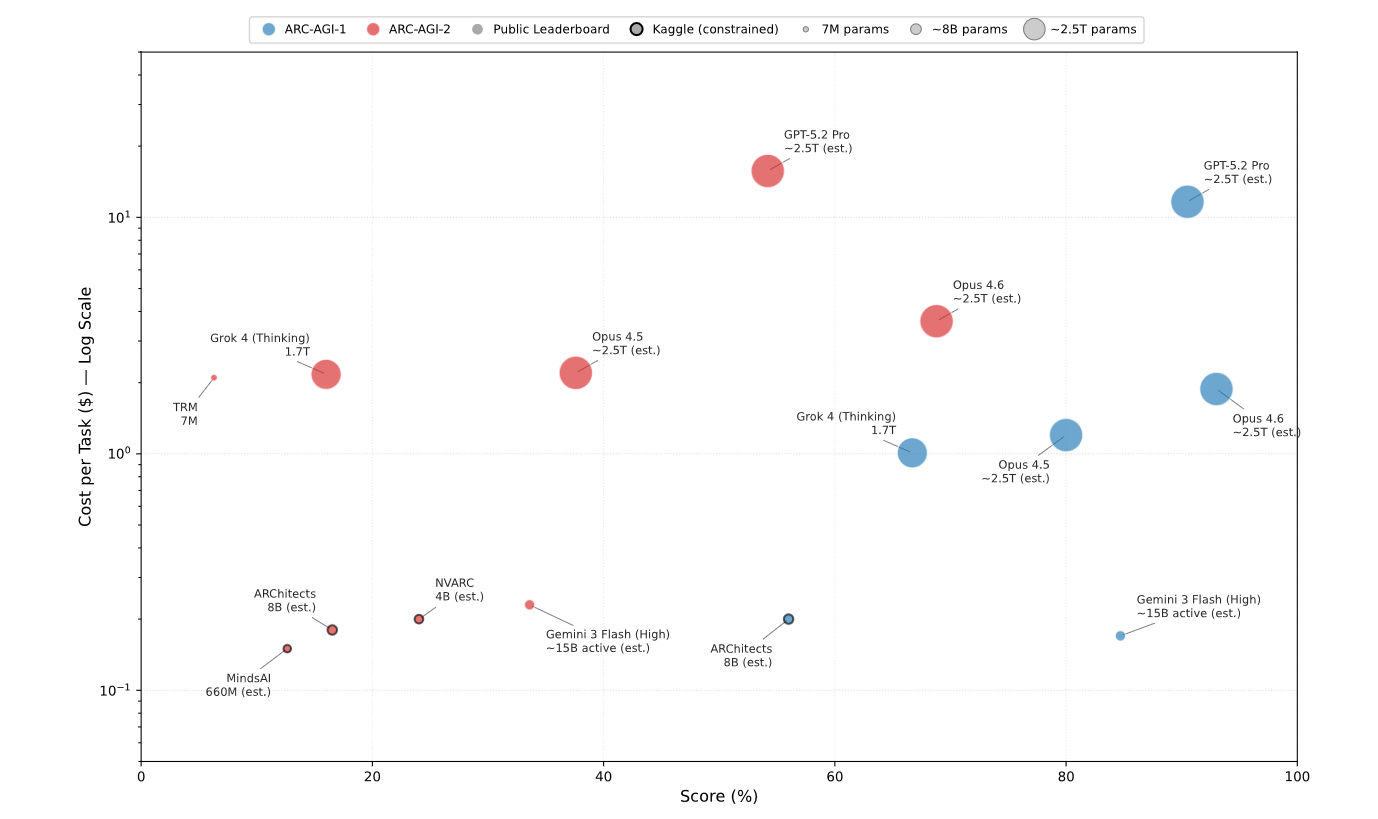

This is a **Bubble Chart**, which is a variation of a scatter plot where the data points are replaced with bubbles, and an additional dimension of the data is represented in the size of the bubbles.

In this specific chart, it tracks the cost-efficiency versus performance of various AI models, utilizing color for task categorization, border style for constraints, and bubble size for parameter count.

Here is a detailed breakdown of the plot's components that you can use as a prompt or instructions to recreate it:

### **Chart Description & Recreation Instructions**

**1. General Layout and Axes**

* **Type:** 2D Bubble Chart.
* **X-axis:** Labeled "Score (%)". It uses a standard linear scale ranging from 0 to 100, with major tick marks and labels placed every 20 units (0, 20, 40, 60, 80, 100).
* **Y-axis:** Labeled "Cost per Task ($) — Log Scale". It uses a logarithmic (base 10) scale. The visible range spans roughly from 0.05 to 50, with major tick labels at 10⁻¹ (0.1), 10⁰ (1.0), and 10¹ (10).
* **Grid & Background:** The background is clean white. A very faint, light grey dotted grid aligns with the major ticks on both the x and y axes. The entire plot area is enclosed by a solid, thin black bounding box.

**2. Legend and Categorical Styling**
Position the legend horizontally at the top center of the chart, enclosed within a thin, rounded rectangular border. It defines three visual dimensions:

* **Color (Task Type):**
* **ARC-AGI-1:** Muted blue fill.
* **ARC-AGI-2:** Salmon/light red fill.
* **Public Leaderboard:** Solid grey fill (used as a baseline key).


* **Border (Constraint):**
* **Kaggle (constrained):** Indicated by a thick, dark grey/black outline around the bubble. Bubbles without this constraint have no border or a very thin one matching their fill color.


* **Size (Parameter Count):**
* **~7M params:** Smallest dot size.
* **~8B params:** Medium dot size.
* **~2.5T params:** Largest dot size. *(Note: Plot the actual data bubbles with continuously scaling sizes based on their specific parameter counts).*



**3. Data Points and Annotations**

* Scatter the bubbles across the plotting area based on their X (Score) and Y (Cost) coordinates. Size them proportionally to the model's parameter count and color them according to their ARC-AGI category.
* Apply the thick black border specifically to the models designated as "Kaggle (constrained)" (predominantly found in the lower-left quadrant, such as MindsAI, ARChtitects, and NVARC).
* **Annotations:** Every single bubble must be labeled.
* Use a thin, straight, dark grey leader line connecting the text to the edge of its corresponding bubble.
* The text must be formatted in a small, dark grey, sans-serif font.
* Split the label into two lines: the top line for the model name (e.g., "GPT-5.2 Pro", "Gemini 3 Flash (High)"), and the bottom line for the parameter count and status (e.g., "~2.5T (est.)", "15B active (est.)").